# Hands-on 2: Simple Linear Regression in Python

**Materia:** Machine Learning 2026B  
**Alumno:** Yahir Valenzuela  
**Docente:** José Antonio Aviña Méndez  

## Objetivo

Analizar la implementación de una Regresión Lineal Simple con Scikit-learn para modelar la relación entre años de experiencia y salario, siguiendo el artículo de Shuvrajyoti Debroy.

## 1. Fundamentos de la técnica SLR

La **Regresión Lineal Simple** utiliza una sola variable independiente para estimar una variable dependiente.

En este ejercicio:

- **X = YearsExperience**: años de experiencia; variable independiente.
- **y = Salary**: salario; variable dependiente.

La finalidad es encontrar una recta que represente la tendencia entre experiencia y salario y permita realizar predicciones.

## 2. Modelo matemático

<div style="background:#f8f9ff; border:1px solid #d9def7; border-radius:14px; padding:18px; margin:12px 0;">
  <h3 style="margin-top:0; color:#2c3e50;">Ecuación de la recta</h3>
  <p>El artículo expresa la relación lineal mediante:</p>

$$
y=mx+c
$$

  <p>que también puede escribirse como:</p>

$$
\hat{y}=\beta_0+\beta_1x
$$

  <ul>
    <li><b>x</b>: años de experiencia.</li>
    <li><b>\hat{y}</b>: salario predicho.</li>
    <li><b>m</b> o <b>\beta_1</b>: pendiente.</li>
    <li><b>c</b> o <b>\beta_0</b>: intercepto.</li>
  </ul>
</div>

<div style="background:#fffaf2; border:1px solid #f0d9a7; border-radius:14px; padding:18px; margin:12px 0;">
  <h3 style="margin-top:0; color:#7a4e00;">Función de error</h3>
  <p>Para evaluar qué tan cerca están las predicciones de los valores reales, puede utilizarse el <b>Mean Squared Error (MSE)</b>:</p>

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(\hat{y_i}-y_i)^2
$$

  <p>Esta expresión resume el error promedio al cuadrado entre los salarios observados y los salarios predichos.</p>
</div>

## 4. Paso 1 — Importar los paquetes necesarios

- `pandas`: lectura y manipulación del dataset.
- `numpy`: operaciones numéricas.
- `matplotlib.pyplot` y `seaborn`: visualización.
- `train_test_split`: división Train/Test.
- `LinearRegression`: modelo de regresión lineal.

`random_state` aparece importado desde `pandas.core.common` en el artículo, aunque después no se utiliza. Se conserva porque forma parte del código analizado.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-huqbo1w8 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Acceso al dataset desde Google Drive

El archivo **Salary_Data.csv** debe estar guardado en:

`Mi unidad/Machine-learning/Salary_Data.csv`

Primero se monta Google Drive para que Colab pueda acceder al archivo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
# Get dataset
df_sal = pd.read_csv(dataset_path)
df_sal.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 6. Paso 3 — Análisis descriptivo

`df_sal.describe()` calcula conteo, media, desviación estándar, mínimo, cuartiles y máximo. Esto permite revisar la escala y distribución de `YearsExperience` y `Salary`.

In [4]:
# Describe data
df_sal.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


### Distribución de los salarios

`plt.title()` define el título.  
`sns.distplot(df_sal['Salary'])` representa la distribución de los salarios.  
`plt.show()` presenta la gráfica.

**Nota técnica:** `seaborn.distplot()` está obsoleta en versiones recientes de Seaborn, pero continúa funcionando en el entorno de esta práctica; se conserva sin sustituirla.

/tmp/ipykernel_1203/3676038920.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_sal['Salary'])


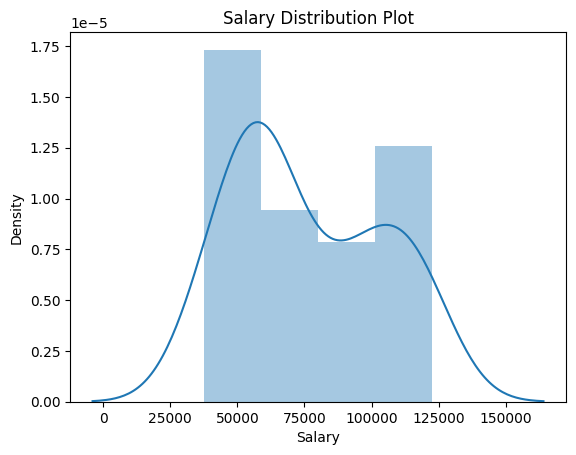

In [5]:
# Data distribution
plt.title('Salary Distribution Plot')
sns.distplot(df_sal['Salary'])
plt.show()

### Relación entre salario y experiencia

`plt.scatter()` representa cada observación con `YearsExperience` en el eje X y `Salary` en el eje Y.  
El resto de las líneas define título, etiquetas, marco y visualización.

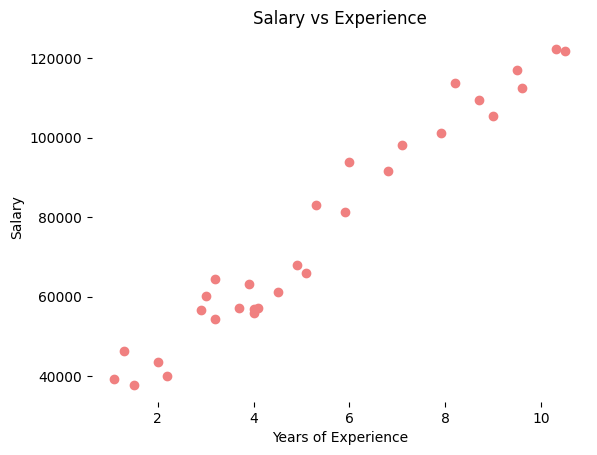

In [6]:
# Relationship between Salary and Experience
plt.scatter(df_sal['YearsExperience'], df_sal['Salary'], color = 'lightcoral')
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.box(False)
plt.show()

## 7. Paso 4 — Separar variables

`X = df_sal.iloc[:, :1]` toma `YearsExperience` como variable independiente.  
`y = df_sal.iloc[:, 1:]` toma `Salary` como variable dependiente.

In [7]:
# Splitting variables
X = df_sal.iloc[:, :1]  # independent
y = df_sal.iloc[:, 1:]  # dependent

## 8. Paso 5 — División Train/Test

`train_test_split()` crea conjuntos de entrenamiento y prueba.  
`test_size=0.2` reserva el 20 % para evaluación y `random_state=0` hace reproducible la partición.

In [8]:
# Splitting dataset into test/train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## 9. Paso 6 — Entrenar el modelo

`LinearRegression()` crea el regresor.  
`fit(X_train, y_train)` calcula el coeficiente y el intercepto a partir del conjunto de entrenamiento.

In [9]:
# Regressor model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 10. Paso 7 — Generar predicciones

`predict(X_test)` genera los salarios predichos para el conjunto de prueba.  
`predict(X_train)` genera las predicciones correspondientes al conjunto de entrenamiento.

In [10]:
# Prediction result
y_pred_test = regressor.predict(X_test)     # predicted value of y_test
y_pred_train = regressor.predict(X_train)   # predicted value of y_train

## 11. Paso 8 — Gráfica del conjunto de entrenamiento

El código original dibuja los puntos reales de entrenamiento y la línea de regresión.

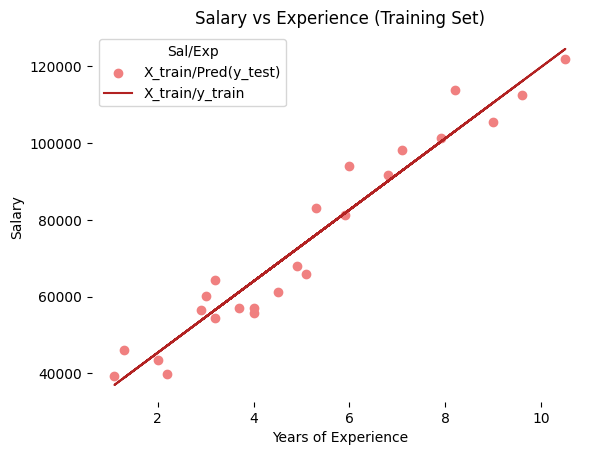

In [11]:
# Prediction on training set
plt.scatter(X_train, y_train, color = 'lightcoral')
plt.plot(X_train, y_pred_train, color = 'firebrick')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(['X_train/Pred(y_test)', 'X_train/y_train'], title = 'Sal/Exp', loc='best', facecolor='white')
plt.box(False)
plt.show()

### Nota técnica sobre la leyenda de entrenamiento

La gráfica se ejecuta, pero las etiquetas de la leyenda no describen correctamente las dos series. La primera serie son los datos reales de entrenamiento y la segunda es la recta de regresión.

La siguiente celda mantiene los mismos datos y colores y corrige únicamente las etiquetas.

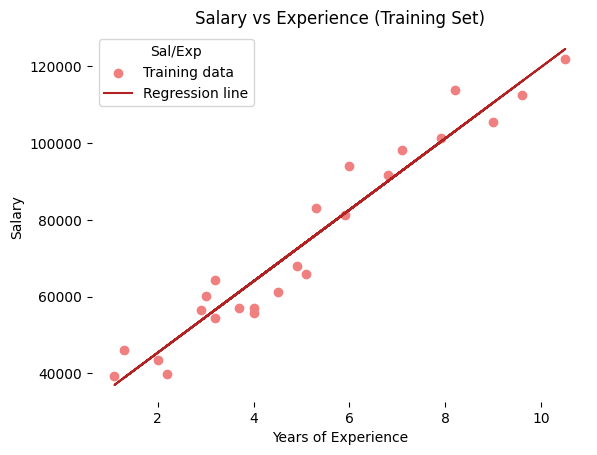

In [12]:
plt.scatter(X_train, y_train, color='lightcoral', label='Training data')
plt.plot(X_train, y_pred_train, color='firebrick', label='Regression line')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(title='Sal/Exp', loc='best', facecolor='white')
plt.box(False)
plt.show()

## 12. Paso 9 — Gráfica del conjunto de prueba

El código original muestra los valores reales de prueba junto con la recta obtenida usando los datos de entrenamiento.

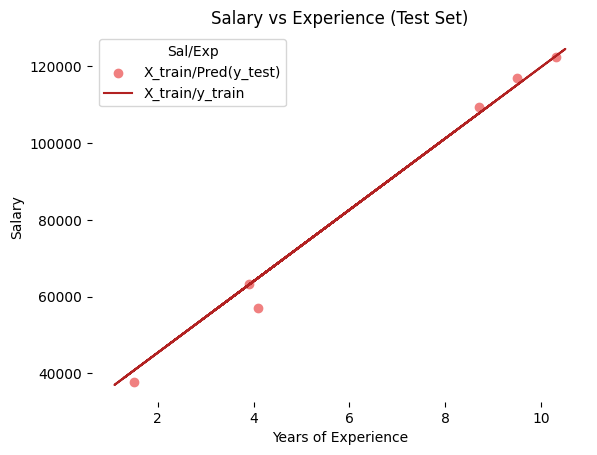

In [13]:
# Prediction on test set
plt.scatter(X_test, y_test, color = 'lightcoral')
plt.plot(X_train, y_pred_train, color = 'firebrick')
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(['X_train/Pred(y_test)', 'X_train/y_train'], title = 'Sal/Exp', loc='best', facecolor='white')
plt.box(False)
plt.show()

### Nota técnica sobre la leyenda de prueba

Los puntos corresponden a `X_test`/`y_test` y la línea corresponde al modelo entrenado. La siguiente celda corrige solamente los textos de la leyenda.

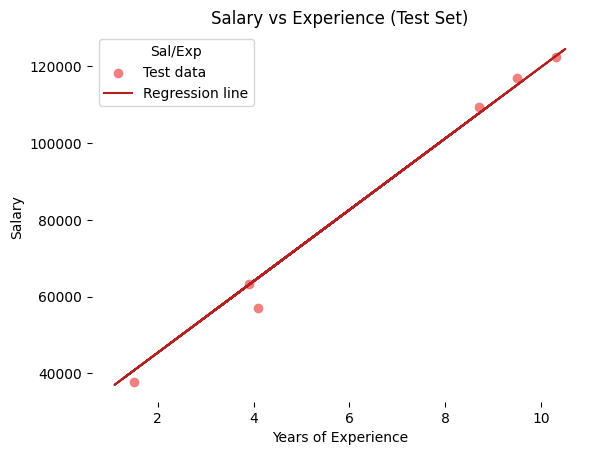

In [14]:
plt.scatter(X_test, y_test, color='lightcoral', label='Test data')
plt.plot(X_train, y_pred_train, color='firebrick', label='Regression line')
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(title='Sal/Exp', loc='best', facecolor='white')
plt.box(False)
plt.show()

## 13. Coeficiente e intercepto

`regressor.coef_` muestra la pendiente aprendida y `regressor.intercept_` el intercepto de la recta.

In [15]:
# Regressor coefficients and intercept
print(f'Coefficient: {regressor.coef_}')
print(f'Intercept: {regressor.intercept_}')

Coefficient: [[9312.57512673]]
Intercept: [26780.09915063]


## 14. Verificación con MAE, MSE y R²

Las métricas se calculan sobre el conjunto de prueba:

- **MAE**: error absoluto promedio.
- **MSE**: error cuadrático promedio.
- **R²**: proporción de la variabilidad del salario explicada por el modelo.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"MAE: {mae:.6f}")
print(f"MSE: {mse:.6f}")
print(f"R²: {r2:.6f}")

MAE: 2446.172369
MSE: 12823412.298127
R²: 0.988170


## Conclusión

El modelo utiliza `YearsExperience` como variable independiente y `Salary` como variable dependiente. `train_test_split()` separa los datos, `LinearRegression()` crea el modelo, `fit()` estima sus parámetros y `predict()` genera las predicciones.

Las gráficas permiten observar el ajuste lineal y MAE, MSE y R² permiten comprobar el desempeño con datos de prueba.

## Referencias

- Debroy, S. (2023, 29 de enero). *Simple Linear Regression in Python*. Medium. https://medium.com/@shuv.sdr/simple-linear-regression-in-python-a0069b325bf8
- Scikit-learn Developers. *LinearRegression*. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Scikit-learn Developers. *train_test_split*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- Scikit-learn Developers. *Regression metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
- Salary Data: https://github.com/sudarshan-koirala/Salary-Prediciton-based-on-Years-of-Experience/blob/master/Salary_Data.csv